In [1]:
import numpy as np
import nibabel as nib
from nilearn import datasets
import os.path as op
import os
import pandas as pd
from brainspace.gradient import GradientMaps
from brainspace.utils.parcellation import map_to_labels
import matplotlib.pyplot as plt

In [2]:
#bids_folder_subjects = '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk/derivatives/glm_stim2.denoise/' #stim 2 includes sub-03
bids_folder_matrices = '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk'
target_dir = op.join(bids_folder_matrices,'derivatives','gradients.glmsingle')
os.makedirs(target_dir, exist_ok=True)

stimuli = ['1', '2']
subList = {}

for stim in stimuli:
    bids_folder_subjects = f'/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk/derivatives/glm_stim{stim}.denoise/'
    subList[stim] = sorted([f[4:6] for f in os.listdir(bids_folder_subjects) 
                if f.startswith("sub-") and len(f) == 6], key=lambda x: int(x))

#subList = sublist_group1

# group list
#df_participants = pd.read_csv(op.join(bids_folder_subjects, 'add_tables','subjects_recruit_scan_scanned-final.csv'), header=0) #, index_col=0
#group_list = df_participants.loc[:,['subject ID','group']].rename(mapper={'subject ID': 'subject'},axis=1).dropna().astype({'subject': int, 'group': int}).set_index('subject')

source_folder = op.join(bids_folder_matrices,'derivatives','correlation_matrices.glmsingle')

specification = '' # align_spec = '_align-procrustes'
ses = 1

In [3]:
import os.path as op
import pandas as pd

home_dir = "/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/phenotype/"
percep_mem_noise = pd.read_csv(op.join(home_dir, "magjudge_bauer-3_sds_unbiased.csv"))

# Prepare containers
sublist_group0 = {'1': [], '2': []}
sublist_group1 = {'1': [], '2': []}

# Group 0: get list of subjects, format as zero-padded strings
g0_raw = percep_mem_noise.loc[percep_mem_noise['group'] == 0, 'subject'].tolist()
g0_formatted = [f"{int(s):02d}" for s in g0_raw]

# Stimulus 1 -> all group 0 subjects
sublist_group0['1'] = [s for s in g0_formatted if s != '03']

# Stimulus 2 -> exclude subject '03' (example)
sublist_group0['2'] = g0_formatted

print("Group 0, stim1:", sublist_group0['1'])
print("Group 0, stim2:", sublist_group0['2'])

# Group 1: same procedure
g1_raw = percep_mem_noise.loc[percep_mem_noise['group'] == 1, 'subject'].tolist()
g1_formatted = [f"{int(s):02d}" for s in g1_raw]

sublist_group1['1'] = g1_formatted
sublist_group1['2'] = g1_formatted  # or apply different exclusion if needed

print("Group 1, stim1:", sublist_group1['1'])
print("Group 1, stim2:", sublist_group1['2'])

Group 0, stim1: ['01', '05', '07', '09', '10', '12', '14', '15', '18', '19', '20', '21', '24', '28', '30', '31', '35', '36', '52', '53', '54', '55', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66']
Group 0, stim2: ['01', '03', '05', '07', '09', '10', '12', '14', '15', '18', '19', '20', '21', '24', '28', '30', '31', '35', '36', '52', '53', '54', '55', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66']
Group 1, stim1: ['02', '04', '06', '08', '11', '13', '16', '17', '22', '23', '25', '26', '27', '29', '32', '33', '34', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '56']
Group 1, stim2: ['02', '04', '06', '08', '11', '13', '16', '17', '22', '23', '25', '26', '27', '29', '32', '33', '34', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '56']


In [56]:
len(subList['1'])

65

In [3]:
from my_utils import get_basic_mask

mask, labeling_noParcel = get_basic_mask()
N_vertices = len(np.where(mask==True)[0])

[fetch_atlas_surf_destrieux] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface


/home/ubuntu/git/parietal_patterns/sophie/my_utils.py:169: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  atlas = datasets.fetch_atlas_surf_destrieux()
/home/ubuntu/git/parietal_patterns/sophie/my_utils.py:169: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  atlas = datasets.fetch_atlas_surf_destrieux()


In [ ]:
# Compute average correlation matrix for all subjects for each stimulus type

#sublists = [sublist_group0, sublist_group1]

stimuli_types = ['1', '2']
#arctanh = '' #'_arctanh'

#for i, sublist in enumerate(sublists):
for stimulus in stimuli_types:
    print(f'Processing {stimulus} ...') #and group {i}
    
    # Initialize zero matrix for averaging
    matrix_zeros = np.zeros((N_vertices, N_vertices))
    av_cm = matrix_zeros.copy()

    for sub in subList[stimulus]:
        try:
            # Load the correlation matrix for the current stimulus type
            correlation_matrix = np.load(op.join(
                source_folder,
                f'sub-{sub}_ses-{ses}_stimulus-{stimulus}_betas_space-fsav5.npy'
            ))
            av_cm += correlation_matrix  # Fisher Z-transformation not needed when input is in z-space
            print(f'Subject {sub} added for {stimulus}')
        except Exception as e:
            print(f'Subject {sub} failed for {stimulus}: {e}')

    # Compute the average correlation matrix
    av_cm = av_cm / len(subList[stimulus])
    #av_cm_transf = np.tanh(av_cm)  # Sanity check: diagonal should be 1!

    # Save the average correlation matrix for the current stimulus type
    np.save(op.join(source_folder,f'cm_av_ses-{ses}_fsav5_unfiltered_stimulus-{stimulus}_glmsingle.npy'), av_cm) #_group-{i}
    print(f'Average correlation matrix saved for stimulus {stimulus}') # group {i}

Processing 2 ...
Subject 01 added for 2
Subject 02 added for 2
Subject 03 added for 2
Subject 04 added for 2
Subject 05 added for 2
Subject 06 added for 2
Subject 07 added for 2
Subject 08 added for 2
Subject 09 added for 2
Subject 10 added for 2
Subject 11 added for 2
Subject 12 added for 2
Subject 13 added for 2
Subject 14 added for 2
Subject 15 added for 2
Subject 16 added for 2
Subject 17 added for 2
Subject 18 added for 2
Subject 19 added for 2
Subject 20 added for 2
Subject 21 added for 2
Subject 22 added for 2
Subject 23 added for 2
Subject 24 added for 2
Subject 25 added for 2
Subject 26 added for 2
Subject 27 added for 2
Subject 28 added for 2
Subject 29 added for 2
Subject 30 added for 2
Subject 31 added for 2
Subject 32 added for 2
Subject 33 added for 2
Subject 34 added for 2
Subject 35 added for 2
Subject 36 added for 2
Subject 37 added for 2
Subject 38 added for 2
Subject 39 added for 2
Subject 40 added for 2
Subject 41 added for 2
Subject 42 failed for 2: [Errno 2] No su

In [15]:
# Compute average correlation matrix for each stimulus for each group

sublists = [sublist_group0, sublist_group1]

stimuli = ['1', '2']

for stim in stimuli:

    for i, sublist in enumerate(sublists):
        print(f'Processing group {i}...')

        # Initialize zero matrix for averaging
        matrix_zeros = np.zeros((N_vertices, N_vertices))
        av_cm = matrix_zeros.copy()

        for sub in sublist[stim]:
            try:
                # Load the correlation matrix for the current stimulus type
                correlation_matrix = np.load(op.join(source_folder, f'sub-{sub}_ses-{ses}_stimulus-{stim}_betas_space-fsav5.npy'))
                av_cm += correlation_matrix  # Fisher Z-transformation not needed when input is in z-space

                print(f'Subject {sub} added for group {i}, stimulus {stim}')
            except Exception as e:
                print(f'Subject {sub} failed for group {i}, stimulus {stim}: {e}')

        # Compute the average correlation matrix
        av_cm = av_cm / len(sublist[stim])
        #av_cm_transf = np.tanh(av_cm)  # Sanity check: diagonal should be 1!

        # Save the average correlation matrix for the current stimulus type
        np.save(op.join(source_folder,f'cm_av_ses-{ses}_fsav5_unfiltered_stimulus-{stim}_glmsingle_group-{i}.npy'), av_cm)
        print(f'Average correlation matrix saved for group {i}')

Processing group 0...
Subject 01 added for group 0, stimulus 1
Subject 05 added for group 0, stimulus 1
Subject 07 added for group 0, stimulus 1
Subject 09 added for group 0, stimulus 1
Subject 10 added for group 0, stimulus 1
Subject 12 added for group 0, stimulus 1
Subject 14 added for group 0, stimulus 1
Subject 15 added for group 0, stimulus 1
Subject 18 added for group 0, stimulus 1
Subject 19 added for group 0, stimulus 1
Subject 20 added for group 0, stimulus 1
Subject 21 added for group 0, stimulus 1
Subject 24 added for group 0, stimulus 1
Subject 28 added for group 0, stimulus 1
Subject 30 added for group 0, stimulus 1
Subject 31 added for group 0, stimulus 1
Subject 35 added for group 0, stimulus 1
Subject 36 added for group 0, stimulus 1
Subject 52 added for group 0, stimulus 1
Subject 53 added for group 0, stimulus 1
Subject 54 added for group 0, stimulus 1
Subject 55 added for group 0, stimulus 1
Subject 57 added for group 0, stimulus 1
Subject 58 added for group 0, stimu

Shape: (18715, 18715)
Type: <class 'numpy.ndarray'>
[[ 0.          0.01065869  0.07458595 ... -0.00796566 -0.00446421
  -0.0042084 ]
 [ 0.01065869  0.         -0.00464495 ... -0.01354196 -0.00913087
  -0.01499575]
 [ 0.07458595 -0.00464495  0.         ...  0.00051469  0.00838168
   0.00717562]
 ...
 [-0.00796566 -0.01354196  0.00051469 ...  0.          0.18328576
   0.02447426]
 [-0.00446421 -0.00913087  0.00838168 ...  0.18328575  0.
   0.20157489]
 [-0.0042084  -0.01499575  0.00717562 ...  0.02447426  0.20157489
   0.        ]]


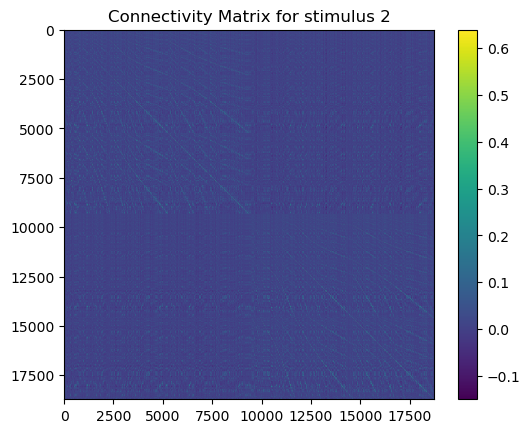

In [35]:
import numpy as np
import os.path as op
import matplotlib.pyplot as plt

# Example subject and stimulus
sub = 'All'
stim = '2'
#group = '0'
#arctanh = '' #_arctanh
ses = '1'

source_folder = '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk/derivatives/correlation_matrices.glmsingle'

# File path #'cm_av_ses-{ses}_fsav5_unfiltered_stimulus-{stimulus}_glmsingle_group-{i}.npy'
file_path = op.join(source_folder, f'cm_av_ses-{ses}_fsav5_unfiltered_stimulus-{stim}_glmsingle.npy') #_group-{group}   sub-{sub}_ses-{ses}_stimulus-{stim}_betas_space-fsav5.npy

# Load the connectivity matrix
connectivity_matrix = np.load(file_path, allow_pickle=True)

# Print basic information
print(f"Shape: {connectivity_matrix.shape}") # 18715, 18715
print(f"Type: {type(connectivity_matrix)}")
print(connectivity_matrix)

# Visualize the matrix
plt.imshow(connectivity_matrix, cmap='viridis')
plt.colorbar()
plt.title(f'Connectivity Matrix for stimulus {stim}')
plt.show()

(array([7.60000000e+01, 2.02000000e+02, 7.55620000e+04, 1.20196440e+07,
        2.00680833e+08, 1.29066356e+08, 7.73344000e+06, 5.93076000e+05,
        7.23000000e+04, 9.73600000e+03]),
 array([-0.56215042, -0.44584557, -0.32954073, -0.21323586, -0.09693101,
         0.01937383,  0.13567871,  0.25198352,  0.3682884 ,  0.48459321,
         0.60089809]),
 <BarContainer object of 10 artists>)

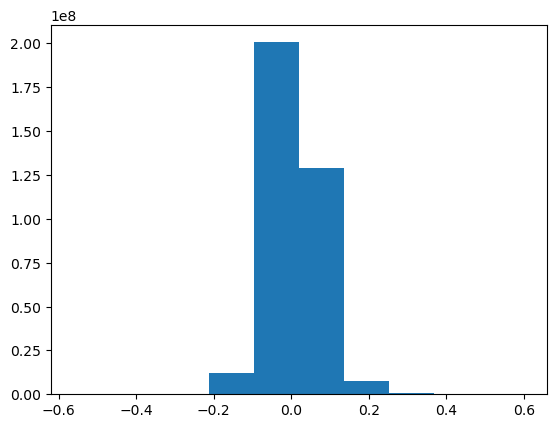

In [8]:
plt.hist(connectivity_matrix.flatten())

In [ ]:
print(np.min(connectivity_matrix), np.max(connectivity_matrix))

# for group 0 stim 1 --> -0.16286875855979135 0.9534981145454143
# for stim 1 no group --> -0.1755429620350623 0.9764788884936941

-0.1755429620350623 0.9764788884936941


In [63]:
file = g_ref

print(g_ref)

[[18.08887351  1.000394   17.2351118  ... -8.1949454  -7.10953017
  -7.93446799]
 [ 4.91693386  3.92922036  3.90748835 ... -8.36617186 -7.43444708
  -7.8901154 ]
 [ 0.30595869  8.25414627 -0.88482355 ... -3.82313623 -3.40383923
  -3.93261909]
 ...
 [ 0.22273171  1.88273362  0.07826032 ... -2.61402835 -2.49592549
  -2.58532474]
 [-1.18600331 -0.8543367   0.39721923 ...  1.24025838  1.44328842
   1.57193948]
 [ 3.26529392 -0.152962    0.52169145 ...  0.05618176 -0.24782721
  -0.0615902 ]]


In [ ]:
from brainspace.gradient import GradientMaps
from brainspace.utils.parcellation import map_to_labels
from my_utils import get_basic_mask
import numpy as np

source_folder = '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk/derivatives/correlation_matrices.glmsingle'
#bids_folder_reference = '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk'
bids_folder_reference = '/mnt_AdaBD_largefiles/Data/DNumrisk_Data/connectivity_references'
bids_folder_matrices = '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk'

mask, labeling_noParcel = get_basic_mask()

sub = 'All'
stimuli = ['1', '2']
#group = '1'
ses = '1'
kernel_var = 'normalized_angle' # None
specification = ''
n_components = 10

if kernel_var == 'None':
    kernel = None
else:
    kernel = kernel_var


for stimulus in stimuli:
    av_cm = np.load(op.join(source_folder, f'cm_av_ses-{ses}_fsav5_unfiltered_stimulus-{stimulus}_glmsingle.npy')) # _group-{group} # sub-{sub}_ses-1_stimulus-{stim}_betas_space-fsav5.npy

    target_dir = op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', f'sub-{sub}')
    if not op.exists(target_dir):
        os.makedirs(target_dir)

    # load in reference gradient and apply same filter
    g_ref = np.load(op.join(bids_folder_reference,'dataset-dnumrisk_sub-All_gradients_kernel-normalized_angle_ztransf-True_avMethod-tanH.npy')) # same labeling_noParcel as cm_unfiltered # 'derivatives','marg_gradients', 'hemi_combined_marg01-10_fsav5_unmasked.npy' # 'derivatives','gradients.tryParams.36P',f'sub-{sub}', f'sub-{sub}_gradients_kernel-{kernel}_ztransf-True_avMethod-tanH.npy'
    g_ref = g_ref[:, mask] #

    # now perform embedding on cleaned data + alignment
    print(f'start fitting gradintes now')
    gm = GradientMaps(n_components=n_components, alignment='procrustes', approach='dm', kernel=kernel, random_state=0) # defaults: approach = 'dm', kernel = normalized_angle
    gm.fit(av_cm,reference=g_ref.T)
    print(f'finished stimulus_{stimulus}: gradients generated')

    np.save(op.join(target_dir,f'stimulus_{stimulus}', f'sub-{sub}_lambdas_space-fsaverag5_n10{specification}_stimulus-{stimulus}_betas_kernel-{kernel}_av-aligned.npy'), gm.lambdas_) # save all together _group-{group}
    gm_= gm.gradients_.T 
    grad = [None] * n_components
    for i, g in enumerate(gm_): # gm.gradients_.T
        grad[i] = map_to_labels(g, labeling_noParcel, mask=mask, fill=np.nan)
    np.save(op.join(target_dir, f'stimulus_{stimulus}', f'sub-{sub}_gradients_space-fsaverag5_n10{specification}_stimulus-{stimulus}_betas_kernel-{kernel}_av-aligned.npy'), grad) # save all together _group-{group}
    gm_ = gm.aligned_.T
    grad = [None] * n_components
    for i, g in enumerate(gm_): # gm.gradients_.T
        grad[i] = map_to_labels(g, labeling_noParcel, mask=mask, fill=np.nan)
    np.save(op.join(target_dir, f'stimulus_{stimulus}', f'sub-{sub}_g-aligned_space-fsaverag5_n10{specification}_stimulus-{stimulus}_betas_kernel-{kernel}_av-aligned.npy'), grad) # save all together _group-{group}

[fetch_atlas_surf_destrieux] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface


/home/ubuntu/git/parietal_patterns/sophie/my_utils.py:169: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  atlas = datasets.fetch_atlas_surf_destrieux()
/home/ubuntu/git/parietal_patterns/sophie/my_utils.py:169: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  atlas = datasets.fetch_atlas_surf_destrieux()


start fitting gradintes now
finished stimulus_1: gradients generated
start fitting gradintes now
finished stimulus_2: gradients generated


In [14]:
bids_folder = '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk'

specification = '' # align_spec = '_align-procrustes'

sub = 'All'
stimuli = ['1', '2'] #

spec = 'g-aligned'  # gradients
kernel = 'normalized_angle' #   None

grad = {'1': [],
        '2': []}

for stim in stimuli:
    target_dir = op.join(bids_folder, 'derivatives', 'gradients.glmsingle', f'sub-{sub}', f'stimulus_{stim}') #, , f'stimulus_{stim}
    grad[stim] = np.load(op.join(target_dir,f'sub-{sub}_{spec}_space-fsaverag5_n10{specification}_stimulus-{stim}_betas_kernel-{kernel}_av-aligned.npy')) 

In [ ]:
import matplotlib.colors as colors

def get_GMmargulies_cmap(skewed=True): 
    # proportion of the two colormaps, defines how much space is taken by each
    first = int((128*2)-np.round(255*(1.-0.90)))
    second = (256-first)
    first = first if skewed else second
    colors2 = plt.cm.viridis(np.linspace(0.1, .98, first))
    colors3 = plt.cm.YlOrBr(np.linspace(0.25, 1, second))

    # combine them and build a new colormap
    cols = np.vstack((colors2,colors3))
    mymap = colors.LinearSegmentedColormap.from_list('my_colormap', cols)
    return mymap


/tmp/ipykernel_156372/2647944808.py:20: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  nplt.plot_surf(surf_mesh= fsaverage.infl_right, surf_map= gm_r, # infl_right # pial_right


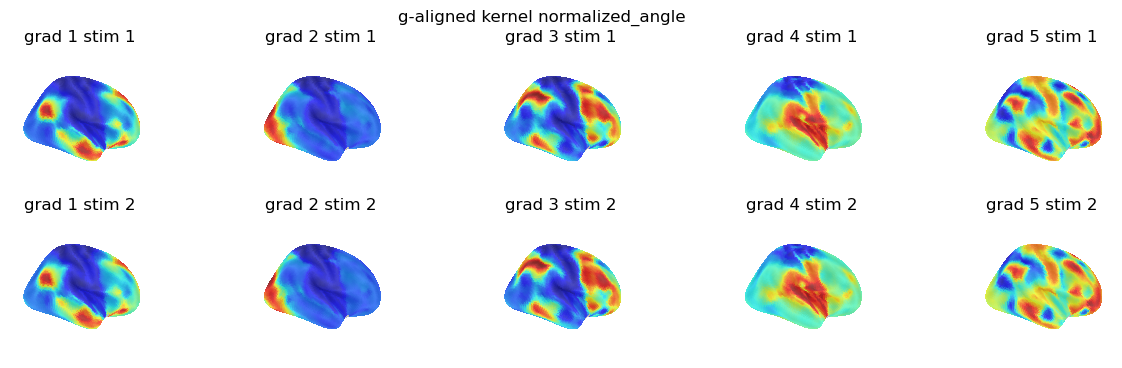

In [7]:
# plotting gradients

import nilearn.plotting as nplt
import matplotlib.pyplot as plt
from  nilearn.datasets import fetch_surf_fsaverage
fsaverage = fetch_surf_fsaverage() # default 5

side_view = 'medial'
cmap = 'jet'
n_comp = 5

figure, axes = plt.subplots(nrows=2, ncols=n_comp,figsize = (15,4), subplot_kw=dict(projection='3d'))

for j, stim in enumerate(stimuli):
    for i in range(0,n_comp):
        gm = np.split(grad[stim][i],2) # for i, hemi in enumerate([‘L’, ‘R’]): --> left first

        gm_r = gm[1]
        
        nplt.plot_surf(surf_mesh= fsaverage.infl_right, surf_map= gm_r, # infl_right # pial_right
                    view= side_view,cmap=cmap, colorbar=False,  # sub-{sub}, title=f’grad {i+1}‘,
                    bg_map=fsaverage.sulc_right, bg_on_data=True,darkness=0.7 ,axes=axes[j, i]) #
        axes[j, i].set(title=f'grad {i+1} stim {stim}')
    figure.suptitle(f'{spec} kernel {kernel}')

/tmp/ipykernel_156372/2867244769.py:43: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  nplt.plot_surf(
/tmp/ipykernel_156372/2867244769.py:57: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  nplt.plot_surf(


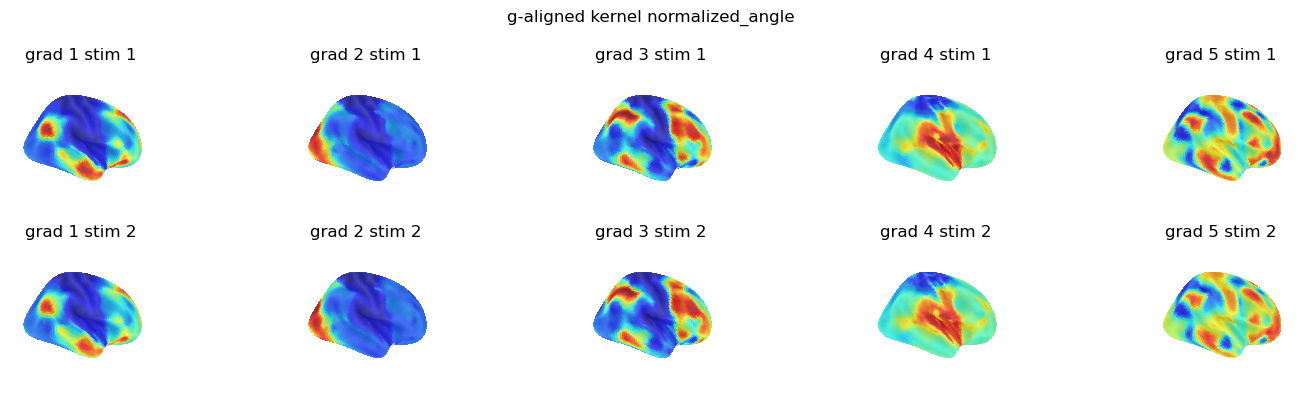

In [ ]:
# code for shared color bar

import nilearn.plotting as nplt
import matplotlib.pyplot as plt
from nilearn.datasets import fetch_surf_fsaverage
import numpy as np

fsaverage = fetch_surf_fsaverage()

side_view = 'medial'
cmap = 'jet'
n_comp = 5

figure, axes = plt.subplots(
    nrows=2,
    ncols=n_comp,
    figsize=(15, 4),
    subplot_kw=dict(projection='3d')
)

# -------------------------
# 1. Compute vmin/vmax from stim 1 ONLY (Nilearn-style)
# -------------------------
vlims = {}

ref_stim = stimuli[0]

for i in range(n_comp):
    gm_l, gm_r = np.split(grad[ref_stim][i], 2)
    vlims[i] = {
        "right": (np.nanmin(gm_r), np.nanmax(gm_r)),
        "left":  (np.nanmin(gm_l), np.nanmax(gm_l))
    }

# -------------------------
# 2. Plot
# -------------------------
for j, stim in enumerate(stimuli):
    for i in range(n_comp):

        gm_l, gm_r = np.split(grad[stim][i], 2)

        if stim == ref_stim:
            # EXACTLY like your old plots
            nplt.plot_surf(
                surf_mesh=fsaverage.infl_right,
                surf_map=gm_r,
                view=side_view,
                cmap=cmap,
                colorbar=False,
                bg_map=fsaverage.sulc_right,
                bg_on_data=True,
                darkness=0.7,
                axes=axes[j, i]
            )
        else:
            # Match stim 1 color scale
            vmin, vmax = vlims[i]["right"]
            nplt.plot_surf(
                surf_mesh=fsaverage.infl_right,
                surf_map=gm_r,
                view=side_view,
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                colorbar=False,
                bg_map=fsaverage.sulc_right,
                bg_on_data=True,
                darkness=0.7,
                axes=axes[j, i]
            )

        axes[j, i].set_title(f'grad {i+1} stim {stim}')

figure.suptitle(f'{spec} kernel {kernel}')
plt.tight_layout()
plt.show()

/tmp/ipykernel_504532/509698991.py:32: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  nplt.plot_surf(


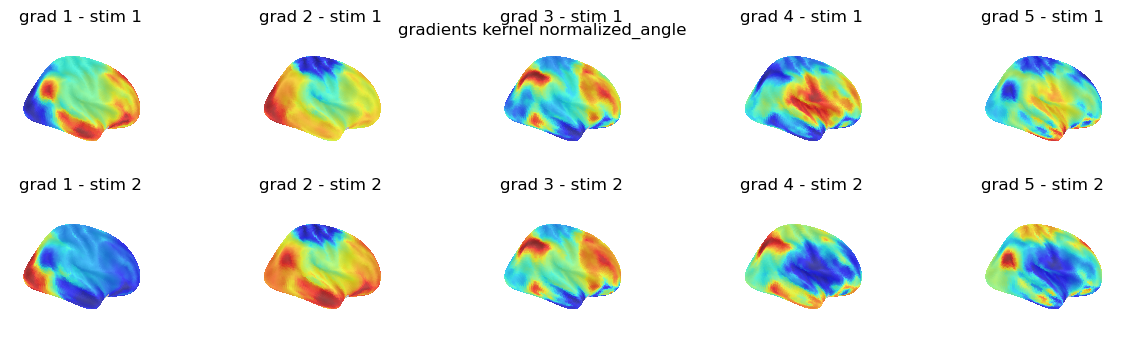

In [ ]:
# code to flip things if needed

import nilearn.plotting as nplt
import matplotlib.pyplot as plt
from nilearn.datasets import fetch_surf_fsaverage

fsaverage = fetch_surf_fsaverage()  # default fsaverage5

side_view = 'medial'
cmap = 'jet'
n_comp = 5

figure, axes = plt.subplots(nrows=2, ncols=n_comp, figsize=(15, 4), subplot_kw=dict(projection='3d'))

for j, stim in enumerate(stimuli):
    for i in range(0, n_comp):
        # Flip grad 1 values if i == 0
        if stim == '1': #  or stim == '2'
            grad_to_plot = -grad[stim][i] if i == 0 or i ==1 else grad[stim][i] #or i == 1
        elif stim == '2':
            grad_to_plot = -grad[stim][i] if i ==1 else grad[stim][i]
        else:
            grad_to_plot = grad[stim][i]
        
        

        # Split into left and right hemispheres
        gm = np.split(grad_to_plot, 2)  # Left first, then right
        gm_r = gm[1]
        
        # Plot the right hemisphere
        nplt.plot_surf(
            surf_mesh=fsaverage.infl_right, surf_map=gm_r,  # infl_right or pial_right
            view=side_view, cmap=cmap, colorbar=False,
            bg_map=fsaverage.sulc_right, bg_on_data=True, darkness=0.7, axes=axes[j, i]
        )
        axes[j, i].set(title=f'grad {i+1} - stim {stim}')
    figure.suptitle(f'{spec} kernel {kernel}', y=0.9)

plt.show()

In [38]:
bids_folder_matrices = '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk'

specification = '' # align_spec = '_align-procrustes'

sub = 'All'
stimuli = ['1', '2']
groups = ['0', '1']
spec = 'gradients'  # g-aligned
kernel = 'normalized_angle' # None
grad = {'0': {'1': [], '2': []},
        '1': {'1': [], '2': []}}

for group in groups:
        for stim in stimuli:
                target_dir = op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', f'sub-{sub}', f'stimulus_{stim}')
                grad[group][stim] = np.load(op.join(target_dir,f'sub-{sub}_{spec}_space-fsaverag5_n10{specification}_stimulus-{stim}_betas_kernel-{kernel}_group-{group}.npy'))

In [21]:
-gm[1]

array([16.28564443, -1.80025867, 15.91756722, ..., -4.73778684,
       -2.58733063, -2.36045972], shape=(10242,))

/tmp/ipykernel_456360/1103253681.py:27: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  nplt.plot_surf(surf_mesh= fsaverage.infl_right, surf_map= gm_r, # infl_right # pial_right


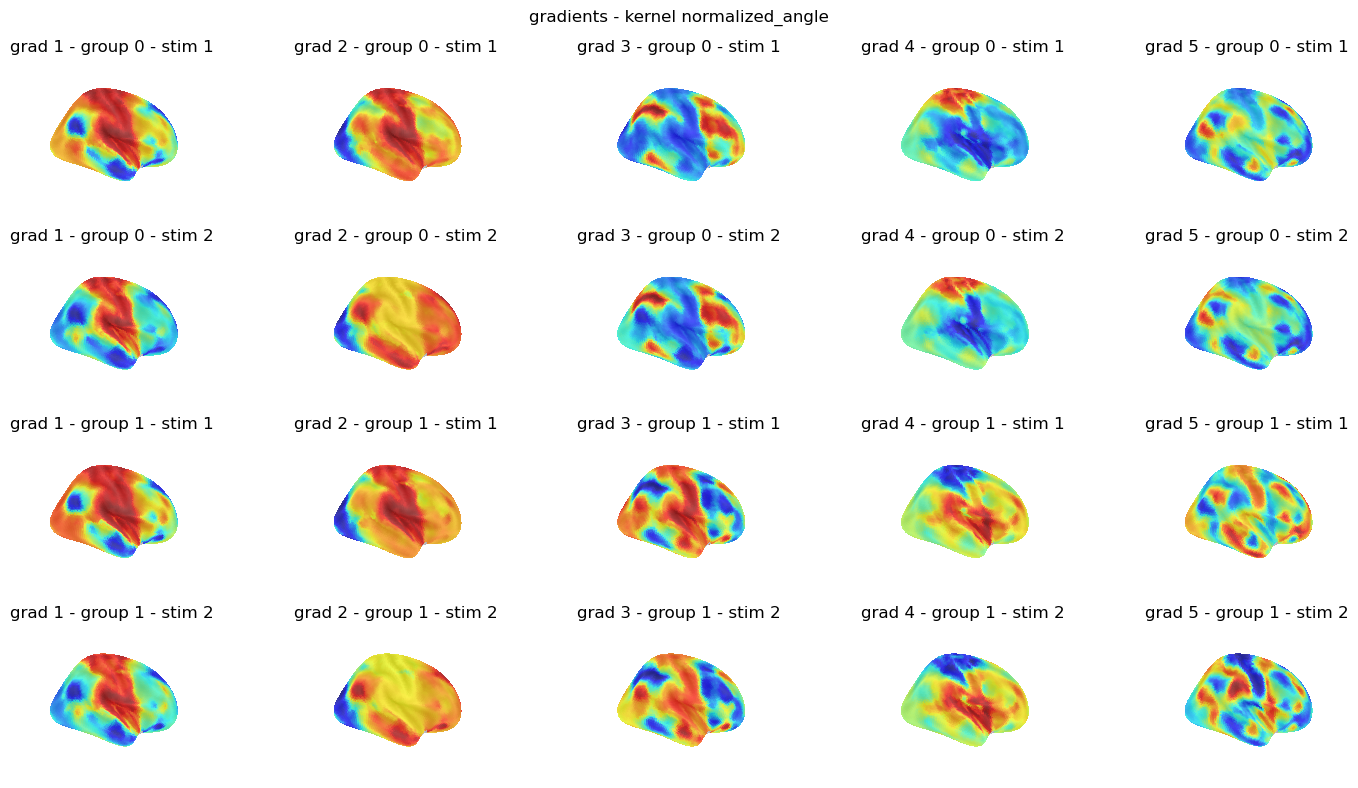

In [43]:
# plotting gradients

import nilearn.plotting as nplt
import matplotlib.pyplot as plt
from  nilearn.datasets import fetch_surf_fsaverage
fsaverage = fetch_surf_fsaverage() # default 5

side_view = 'medial'
cmap = 'jet'
n_comp = 5

figure, axes = plt.subplots(nrows=4, ncols=n_comp,figsize = (15,8), subplot_kw=dict(projection='3d'))

row = 0
for j, group in enumerate(groups):
    for m, stim in enumerate(stimuli):
        for i in range(0,n_comp):
            gm = np.split(grad[group][stim][i],2) # for i, hemi in enumerate([‘L’, ‘R’]): --> left first

            if i == 0 and stim == '1' and group == '0' or group == '1' or i == 1 : #  ' and i == 0 # and stim == '2' and group == '0' 
                gm_r = -gm[1]
            else:
                gm_r = gm[1]

            #gm_r = gm[1]

            nplt.plot_surf(surf_mesh= fsaverage.infl_right, surf_map= gm_r, # infl_right # pial_right
                        view= side_view,cmap=cmap, colorbar=False,  # sub-{sub}, title=f’grad {i+1}‘,
                        bg_map=fsaverage.sulc_right, bg_on_data=True,darkness=0.7 ,axes=axes[row, i]) #
            axes[row, i].set(title=f'grad {i+1} - group {group} - stim {stim}')
        row += 1
        figure.suptitle(f'{spec} - kernel {kernel}') #, y(0.9)
plt.tight_layout()
plt.show()

In [28]:
# plot lambdas

from kneed import KneeLocator #  knee point is the point of maximum curvature.

sub = 'All'
n_comp=10
stimuli_types = ['1', '2']

# Loop through each stimulus
for stimulus in stimuli_types:
    print(f"Processing {stimulus}...")

    fn_lambdas = op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', f'sub-{sub}', f'stimulus_{stimulus}',f'sub-{sub}_lambdas_space-fsaverag5_n10{specification}_stimulus_{stimulus}_betas.npy')
    lambdas = np.load(fn_lambdas)
    
    # Find the knee point
    kneedle = KneeLocator(x=range(1, len(lambdas) + 1), y=lambdas, S=1.0, curve="convex", direction="decreasing")
    
    # Plot the knee
    plt.figure()
    kneedle.plot_knee()
    plt.title(f"Knee Plot for {stimulus}")
    plt.xlabel("Component")
    plt.ylabel("Lambda")

    # Save the plot
    output_plot_path = op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', f'sub-{sub}', f'stimulus_{stimulus}', f'sub-{sub}_knee_plot_{stimulus}_betas.png')
    plt.savefig(output_plot_path)
    plt.close()
    print(f"Saved knee plot for {stimulus} at {output_plot_path}")

Processing 1...
Saved knee plot for 1 at /mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk/derivatives/gradients.glmsingle/sub-All/stimulus_1/sub-All_knee_plot_1_betas.png
Processing 2...
Saved knee plot for 2 at /mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk/derivatives/gradients.glmsingle/sub-All/stimulus_2/sub-All_knee_plot_2_betas.png


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

Processing ['1', '2']...
Processing ['1', '2']...


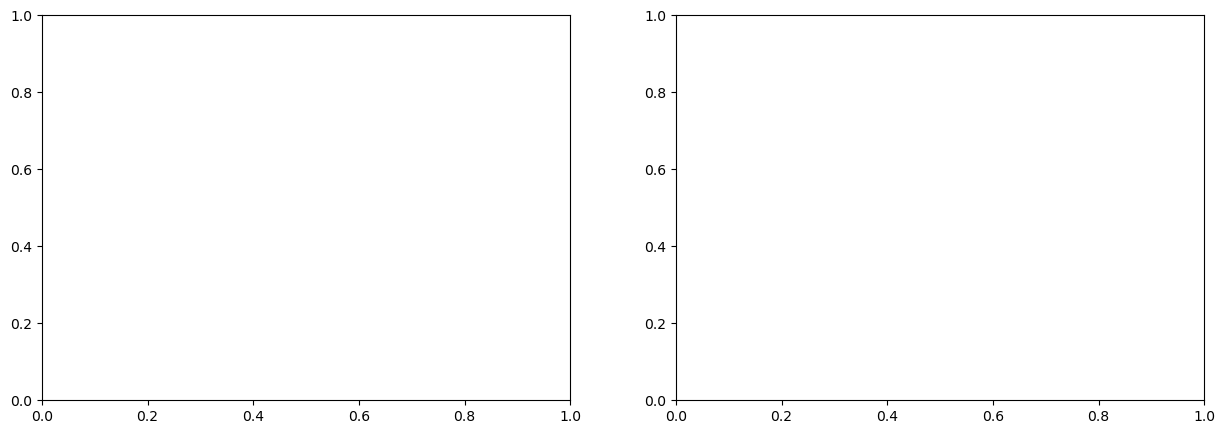

<Figure size 640x480 with 0 Axes>

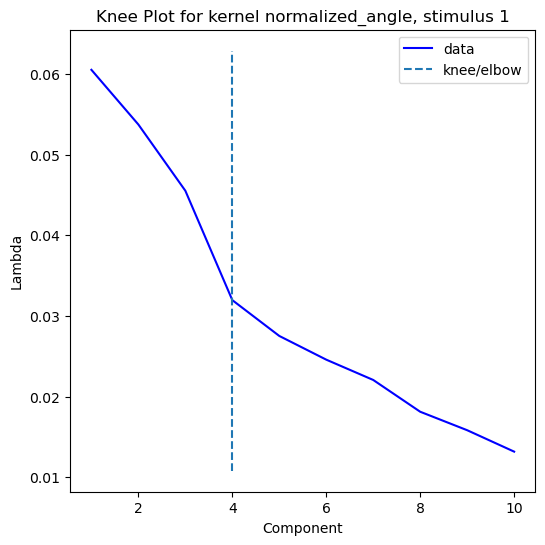

<Figure size 640x480 with 0 Axes>

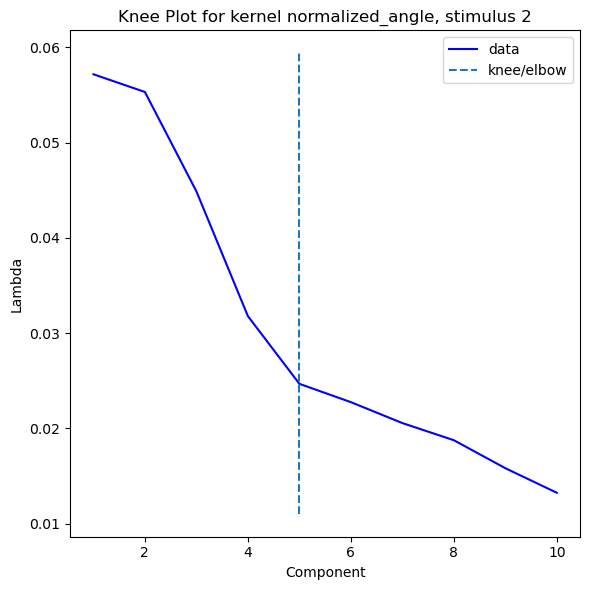

In [8]:
# kneeplots
from kneed import KneeLocator

# Parameters
bids_folder = '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk/' 
specification = '' # align_spec = '_align-procrustes' 
n_grads = 3 

sub = 'All' 
stimuli = ['1', '2']
n_comp=10

spec = 'lambdas' 
kernel = 'normalized_angle' #  None

var_explained = {'1': [],
                 '2': []}

# Initialize figure for side-by-side visualization
fig, axes = plt.subplots(1, len(stimuli), figsize=(15, 5))  # 1 row, 3 columns

# Loop through each stimulus
for i, stim in enumerate(stimuli):
    print(f"Processing {stimuli}...")

    fn_lambdas = op.join(bids_folder, 'derivatives', 'gradients.glmsingle', f'sub-{sub}', f'stimulus_{stim}', f'sub-{sub}_{spec}_space-fsaverag5_n10_stimulus-{stim}_betas_kernel-{kernel}.npy')
    lambdas = np.load(fn_lambdas)
    
    # Find the knee point
    kneedle = KneeLocator(x=range(1, len(lambdas) + 1), y=lambdas, S=1.0, curve="convex", direction="decreasing")
    
    # Plot the knee
    plt.figure()
    kneedle.plot_knee()
    plt.title(f"Knee Plot for kernel {kernel}, stimulus {stim}")
    plt.xlabel("Component")
    plt.ylabel("Lambda")

    # look at how much variance is explained by the gradients
    var_explained[stim] = lambdas / np.sum(lambdas) * 100

# Adjust layout and show the combined visualization
plt.tight_layout()
plt.show()

In [9]:
print(var_explained['1'])
print(var_explained['2'])

[19.33340985 17.16584356 14.54269258 10.21002323  8.79154988  7.85218488
  7.04803159  5.78917243  5.05778152  4.20931049]
[18.75054451 18.14028244 14.71815093 10.42270962  8.09163894  7.46049562
  6.74017647  6.14968074  5.18614734  4.3401734 ]


FileNotFoundError: [Errno 2] No such file or directory: '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk/derivatives/gradients.glmsingle/sub-All/stimulus_1/sub-All_knee_plot_1_betas.png'

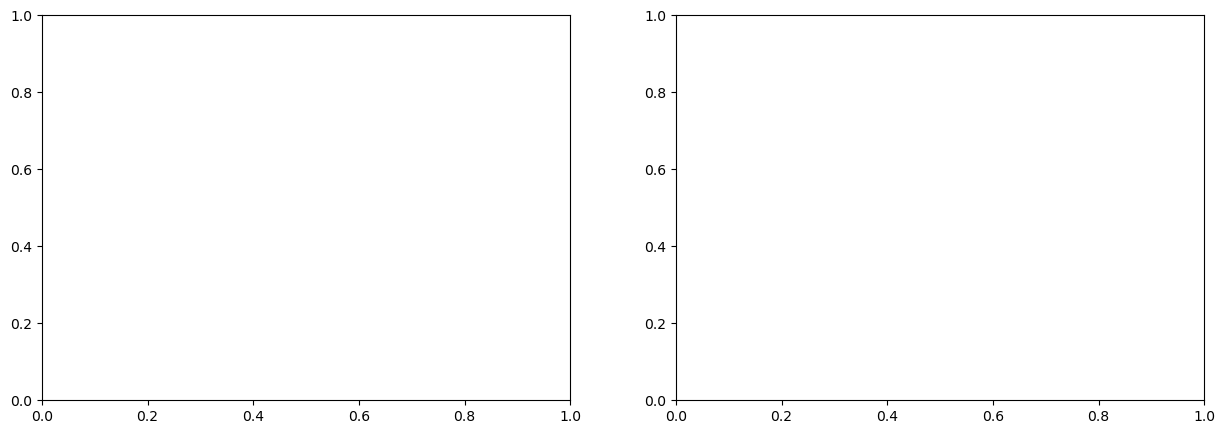

In [4]:
import matplotlib.pyplot as plt
import os.path as op

# Parameters
sub = 'All'
stimuli_types = ['1', '2']

# Initialize figure for side-by-side visualization
fig, axes = plt.subplots(1, len(stimuli_types), figsize=(15, 5))  # 1 row, 3 columns

# Loop through each stimulus to load and display the saved plots
for i, stimulus in enumerate(stimuli_types):
    # File path to the saved plot
    plot_path = op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', f'sub-{sub}', f'stimulus_{stimulus}', f'sub-{sub}_knee_plot_{stimulus}_betas.png')
    
    # Load and display the saved plot
    img = plt.imread(plot_path)
    ax = axes[i]
    ax.imshow(img)
    ax.axis('off')  # Turn off axes for better visualization
    ax.set_title(f"Knee Plot for stimulus {stimulus}")

# Adjust layout and show the combined visualization
plt.tight_layout()
plt.show()

Processing comparison: stimulus 1 vs stimulus 2...
Correlation Matrix for 1 vs 2:
[[0.99603095 0.15259717 0.00519985 0.49257325 0.11525964]
 [0.15392174 0.99535514 0.47255909 0.19236825 0.03584013]
 [0.01908942 0.49555236 0.98899353 0.2559499  0.23989742]
 [0.48777819 0.203557   0.2342287  0.99486972 0.31288861]
 [0.10392541 0.02303733 0.23026164 0.28952345 0.99218454]]


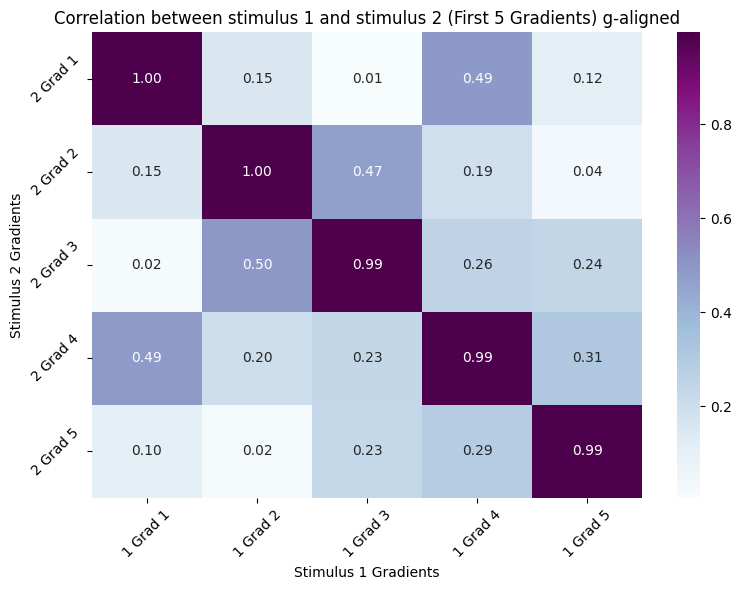

In [34]:
# plot correlation matrix checking similarity between stim 1 and stim 2, stim 1 and remaining, stim 2 and remaining

from neuromaps.stats import compare_images
import numpy as np
import os.path as op
import seaborn as sns
import matplotlib.pyplot as plt

# Parameters
sub = 'All'
spec = 'g-aligned'  # gradients
stimuli_pairs = [
    ('1', '2')
]

n_gradients_to_compare = 5  # Compare only the first 5 gradients

# Loop over stimulus pairs and calculate correlations
for stim1, stim2 in stimuli_pairs:
    print(f"Processing comparison: stimulus {stim1} vs stimulus {stim2}...")
    
    # File paths to the gradient files
    grad1_file = op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', f'sub-{sub}', f'stimulus_{stim1}', f'sub-{sub}_{spec}_space-fsaverag5_n10_stimulus_{stim1}_betas.npy')
    grad2_file = op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', f'sub-{sub}', f'stimulus_{stim2}', f'sub-{sub}_{spec}_space-fsaverag5_n10_stimulus_{stim2}_betas.npy')
    
    # Load the gradients
    grad1 = np.load(grad1_file)[:n_gradients_to_compare]  # Load first 5 gradients
    grad2 = np.load(grad2_file)[:n_gradients_to_compare]  # Load first 5 gradients
    
    # Initialize correlation matrix for this pair
    correlation_matrix = np.zeros((n_gradients_to_compare, n_gradients_to_compare))
    
    # Compute correlations between gradients
    for i in range(n_gradients_to_compare):
        for j in range(n_gradients_to_compare):
            corrcoef = compare_images(grad1[i], grad2[j], metric='pearsonr')
            correlation_matrix[i, j] = np.abs(corrcoef)
    
    # Print the correlation matrix
    print(f"Correlation Matrix for {stim1} vs {stim2}:")
    print(correlation_matrix)
    
    # Plot the correlation matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="BuPu",
                xticklabels=[f'{stim1} Grad {i+1}' for i in range(n_gradients_to_compare)],
                yticklabels=[f'{stim2} Grad {i+1}' for i in range(n_gradients_to_compare)])
    plt.title(f"Correlation between stimulus {stim1} and stimulus {stim2} (First {n_gradients_to_compare} Gradients) {spec}")
    plt.xlabel(f"Stimulus {stim1} Gradients")
    plt.ylabel(f"Stimulus {stim2} Gradients")
    
    # Rotate the x-axis labels
    plt.xticks(rotation=45)
    plt.yticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [6]:
from my_utils import get_glasser_parcels, get_glasser_CAatlas_mapping
import os
import hcp_utils as hcp
from matplotlib.colors import ListedColormap
import seaborn as sns

rgb = np.array(list(hcp.ca_network['rgba'].values())[1:])
ca_cmap = ListedColormap(np.vstack(([1, 1, 1, 1], rgb)), 'custom_colormap') # add white infront, 0=unknown, 1-12 actual labels

# Update the function to use the correct path
mask_glasser, labeling_glasser = get_glasser_parcels(space='fsaverage5')
glasser_CAatlas_mapping, CAatlas_names = get_glasser_CAatlas_mapping()

from brainspace.utils.parcellation import map_to_labels
caNets_fsav5_mapping = map_to_labels(
    glasser_CAatlas_mapping['ca_network'].values,
    labeling_glasser,
    mask=mask_glasser
)

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


In [54]:
CAatlas_names['Network Name']

Label Number
1                  Visual1
2                  Visual2
3              Somatomotor
4        Cingulo-Opercular
5         Dorsal-attention
6                 Language
7           Frontoparietal
8                 Auditory
9                  Default
10    Posterior-Multimodal
11      Ventral-Multimodal
12        Orbito-Affective
Name: Network Name, dtype: object

In [55]:
print(CAatlas_names)

                      Network Name
Label Number                      
1                          Visual1
2                          Visual2
3                      Somatomotor
4                Cingulo-Opercular
5                 Dorsal-attention
6                         Language
7                   Frontoparietal
8                         Auditory
9                          Default
10            Posterior-Multimodal
11              Ventral-Multimodal
12                Orbito-Affective


In [4]:
# plot gradients with assigning the precision functional mapping maps

map_dir = "/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/networks_infomap_full/"

precis_map = np.load(op.join(map_dir, f"sub-All_ses-1_task-magjudge_consensusMapping_threshs-0.03-0.04-0.05-0.1-0.2-0.4_confspec-36Pscrub3BPfilterrunFD104.npy"))


[fetch_atlas_surf_destrieux] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface
Processing 1...


/home/ubuntu/git/parietal_patterns/sophie/my_utils.py:169: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  atlas = datasets.fetch_atlas_surf_destrieux()
/home/ubuntu/git/parietal_patterns/sophie/my_utils.py:169: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  atlas = datasets.fetch_atlas_surf_destrieux()


Processing 2...


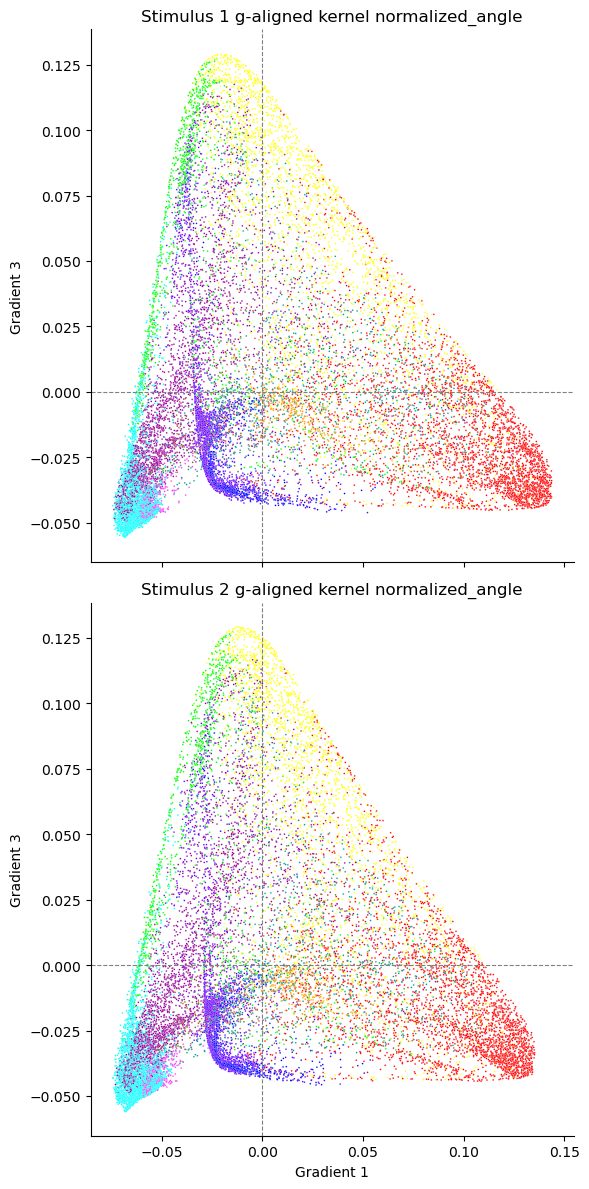

In [12]:
import numpy as np
import os.path as op
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from my_utils import get_basic_mask

bids_folder_matrices = '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk'

mask, labeling_noParcel = get_basic_mask()

sub = 'All'
stimuli_types = ['1', '2']
spec = 'g-aligned'  # gradients
kernel = 'normalized_angle' # None
network_map = caNets_fsav5_mapping[mask] # only ca map needs to be masked!! #  precis_map

# Create a dictionary mapping network names to colors
network_colors = {name: color for name, color in zip(CAatlas_names['Network Name'], ca_cmap.colors[1:])}

# Placeholder for results
correlation_results = {}

# Create subplots for each stimulus
fig, axs = plt.subplots(len(stimuli_types), 1, figsize=(6, 12), sharex=True, sharey=True)



for i, stimulus in enumerate(stimuli_types):  # Use enumerate to get the index (i) and stimulus name
    print(f'Processing {stimulus}...')
    
    try:
        # Load the combined gradient matrix for the current stimulus
        gradients = np.load(op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', 
                                     f'sub-{sub}', f'stimulus_{stimulus}', 
                                     f'sub-{sub}_{spec}_space-fsaverag5_n10_stimulus-{stimulus}_betas_kernel-{kernel}_av-aligned.npy'))

        if stimulus == '1':
            # Extract the first two rows (Gradient 1 and Gradient 2)
            grad1 = gradients[0, :][mask]  # First row: Gradient 1, need to flip this gradient
            grad2 = gradients[1, :][mask]  # Second row: Gradient 2
            grad3 = gradients[2, :][mask]  # Second row: Gradient 3
        
        else:
            # Extract the first two rows (Gradient 1 and Gradient 2)
            grad1 = gradients[0, :][mask]  # First row: Gradient 1, need to flip this gradient for stim 2
            grad2 = gradients[1, :][mask]  # Second row: Gradient 2, need to flip this gradient for stim 2
            grad3 = gradients[2, :][mask]  # Second row: Gradient 3


        # Create a DataFrame for plotting
        df = pd.DataFrame({
            'Gradient 1': grad1,
            'Gradient 2': grad2,
            'Gradient 3': grad3,
            'ca_network': network_map #   # Map network indices to vertices [stim]
        })

        # Map network names to the ca_network column
        df['ca_network_name'] = df['ca_network'].map(CAatlas_names['Network Name'])

        # Scatter plot of Gradient 1 vs Gradient 2
        sns.scatterplot(data=df, x='Gradient 1', y='Gradient 3', hue='ca_network_name', 
                        palette=network_colors, s=1.4, legend=False, ax=axs[i])
        axs[i].set(title=f'Stimulus {stimulus} {spec} kernel {kernel}', xlabel='Gradient 1', ylabel='Gradient 3') # mapping to beta derived precision mapping map
        axs[i].axhline(0, color='gray', linestyle='--', linewidth=0.8)
        axs[i].axvline(0, color='gray', linestyle='--', linewidth=0.8)

    except Exception as e:
        print(f'Failed to process {stimulus}: {e}')

# Adjust layout and remove spines
plt.tight_layout()
sns.despine()
plt.show()

Processing comparison: Stimulus 1 vs stimulus reference_grad...
Correlation Matrix for 1 vs reference_grad:
[[0.84987484 0.42559056 0.05010926 0.24661903 0.03502965]
 [0.30446613 0.84149631 0.2583851  0.29463453 0.07136854]
 [0.21876794 0.13506821 0.21151142 0.59020044 0.69098061]
 [0.16545882 0.10132641 0.76452934 0.42850219 0.22247237]
 [0.24879068 0.19035171 0.32329036 0.35419297 0.52642362]]


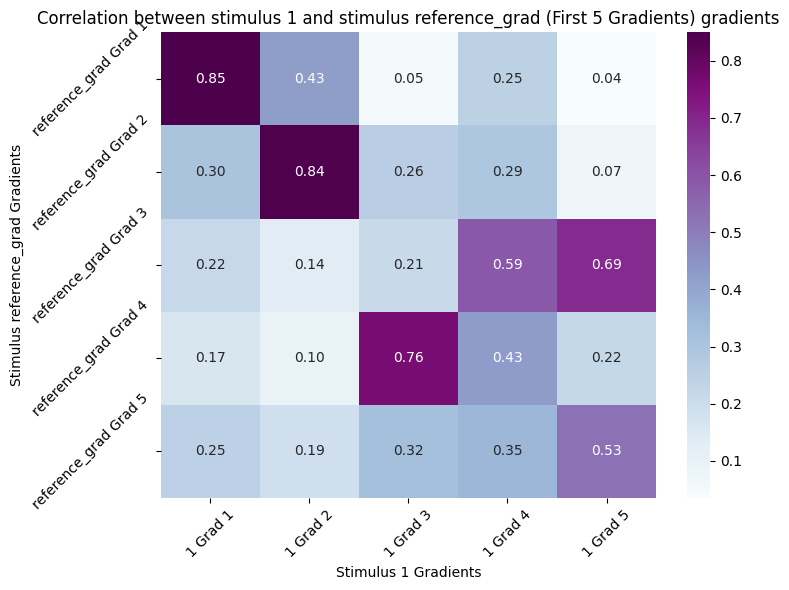

Processing comparison: Stimulus 2 vs stimulus reference_grad...
Correlation Matrix for 2 vs reference_grad:
[[0.83548761 0.45074435 0.1045663  0.24087861 0.0643412 ]
 [0.30895894 0.83865827 0.23889649 0.32701824 0.01779364]
 [0.23291336 0.21280007 0.24131007 0.6573403  0.59539173]
 [0.1525107  0.1243084  0.80398921 0.40335502 0.20028271]
 [0.2651612  0.20497583 0.36804236 0.35641503 0.63312875]]


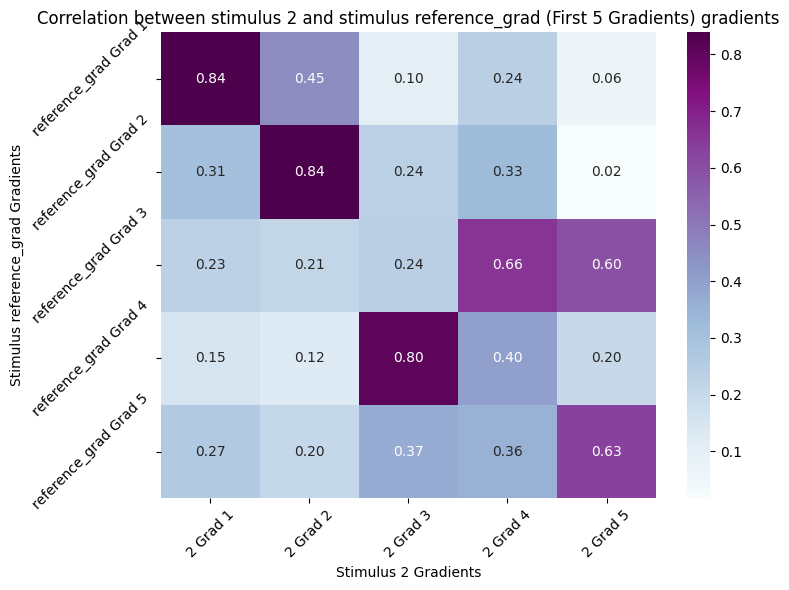

In [40]:
# correlation matrices between unaligned gradients and whole task gradients

from neuromaps.stats import compare_images
import numpy as np
import os.path as op
import seaborn as sns
import matplotlib.pyplot as plt


# Parameters
sub = 'All'
spec = 'gradients' 
stimuli_pairs = [
    ('1', 'reference_grad'),
    ('2', 'reference_grad')
]

n_gradients_to_compare = 5  # Compare only the first 5 gradients

# Loop over stimulus pairs and calculate correlations
for stim1, stim2 in stimuli_pairs:
    print(f"Processing comparison: Stimulus {stim1} vs stimulus {stim2}...")
    
    # File paths to the gradient files
    grad1_file = op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', f'sub-{sub}', f'stimulus_{stim1}', f'sub-{sub}_{spec}_space-fsaverag5_n10_stimulus_{stim1}_betas.npy')
    grad2_file = op.join(bids_folder_subjects,'derivatives', 'gradients','sub-All/sub-All_gradients_N-10.npy')
    
    # Load the gradients
    grad1 = np.load(grad1_file)[:n_gradients_to_compare]  # Load first 5 gradients
    grad2 = np.load(grad2_file)[:n_gradients_to_compare]  # Load first 5 gradients

    # Initialize correlation matrix for this pair
    correlation_matrix = np.zeros((n_gradients_to_compare, n_gradients_to_compare))
    
    # Compute correlations between gradients
    for i in range(n_gradients_to_compare):
        for j in range(n_gradients_to_compare):
            corrcoef = compare_images(grad1[i], grad2[j], metric='pearsonr')
            correlation_matrix[i, j] = np.abs(corrcoef)
    
    # Print the correlation matrix
    print(f"Correlation Matrix for {stim1} vs {stim2}:")
    print(correlation_matrix)
    
    # Plot the correlation matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="BuPu",
                xticklabels=[f'{stim1} Grad {i+1}' for i in range(n_gradients_to_compare)],
                yticklabels=[f'{stim2} Grad {i+1}' for i in range(n_gradients_to_compare)])
    plt.title(f"Correlation between stimulus {stim1} and stimulus {stim2} (First {n_gradients_to_compare} Gradients) {spec}")
    plt.xlabel(f"Stimulus {stim1} Gradients")
    plt.ylabel(f"Stimulus {stim2} Gradients")
    
    # Rotate the x-axis labels
    plt.xticks(rotation=45)
    plt.yticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [51]:
import numpy as np

network_path = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/networks_infomap_full/sub-All_ses-1_task-magjudge_consensusMapping_threshs-0.03-0.04-0.05-0.1-0.2-0.4_confspec-36Pscrub3BPfilterrunFD104.npy'
prec_network = np.load(network_path)

In [59]:
network_file.shape

(18715,)

In [ ]:
# two-sample t-tests between network positions of stim 1 and stim 2 on the first gradient

import numpy as np
import os
import os.path as op
import pandas as pd
from my_utils import get_basic_mask

sub = 'All'
stimuli_types = ['1', '2']
spec = 'g-aligned' # gradients
kernel = 'None' # normalized_angle
network_atlas = 'CAatlas' #   precismap-timeseries

network_file = caNets_fsav5_mapping[mask]  # prec_network

mask, labeling_noParcel = get_basic_mask()

# Directory to save the DataFrames
output_dir = op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle')

for stimulus in stimuli_types:
    print(f'Processing {stimulus}...')
    
    try:
        # Load the combined gradient matrix for the current stimulus
        gradients = np.load(op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', 
                                     f'sub-{sub}', f'stimulus_{stimulus}', 
                                     f'sub-{sub}_{spec}_space-fsaverag5_n10_stimulus-{stimulus}_betas_kernel-{kernel}.npy'))

        # Extract the gradient corresponding rows
        grad1 = -gradients[0, :][mask]  # First row: Gradient 1
        grad2 = -gradients[1, :][mask]  # Second row: Gradient 2
        grad3 = gradients[2, :][mask]  # Third row: Gradient 3

        # Create a DataFrame
        df = pd.DataFrame({
            'Gradient 1': grad1,
            'Gradient 2': grad2,
            'Gradient 3': grad3,
            'ca_network': network_file  # Map network indices to vertices
        })

        # Map network names to the ca_network column
        df['ca_network_name'] = df['ca_network'].map(CAatlas_names['Network Name'])

        # Save the DataFrame to a CSV file
        output_file = op.join(output_dir, f'stim-{stimulus}_dataframe_network-{network_atlas}_kernel-{kernel}.csv')
        df.to_csv(output_file, index=False)
        print(f'Saved DataFrame for {stimulus} to {output_file}')

    except Exception as e:
        print(f'Failed to process {stimulus}: {e}')

[fetch_atlas_surf_destrieux] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface
Processing 1...


/home/ubuntu/git/parietal_patterns/sophie/my_utils.py:169: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  atlas = datasets.fetch_atlas_surf_destrieux()
/home/ubuntu/git/parietal_patterns/sophie/my_utils.py:169: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  atlas = datasets.fetch_atlas_surf_destrieux()


Saved DataFrame for 1 to /mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk/derivatives/gradients.glmsingle/stim-1_dataframe_network-CAatlas_kernel-None.csv
Processing 2...
Saved DataFrame for 2 to /mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk/derivatives/gradients.glmsingle/stim-2_dataframe_network-CAatlas_kernel-None.csv


In [89]:
sub = 'All'
stimuli_types = ['1', '2']
spec = 'g-aligned' # gradients
kernel = 'normalized_angle' #  None
network_atlas = 'precismap-timeseries' #    CAatlas

In [90]:
# t-test to compare network positions between stimulus_1 and stimulus_2

import pandas as pd
from scipy.stats import ttest_rel
import os.path as op


# Load the saved DataFrames for stimulus_1 and stimulus_2
stim1_df = pd.read_csv(op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', f'stim-1_dataframe_network-{network_atlas}_kernel-{kernel}.csv'))
stim2_df = pd.read_csv(op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', f'stim-2_dataframe_network-{network_atlas}_kernel-{kernel}.csv'))

# Initialize a dictionary to store t-test results
t_test_results = {}

gradients = ['1', '2', '3']

for grad in gradients:

    # Perform two-sample t-tests for each network
    for network in stim1_df['ca_network_name'].unique():
        if pd.isna(network):
            continue
        # Filter data for the current network and convert to DataFrame
        stim1_values = stim1_df[stim1_df['ca_network_name'] == network][[f'Gradient {grad}']]
        stim2_values = stim2_df[stim2_df['ca_network_name'] == network][[f'Gradient {grad}']]

        
        # Perform the t-test if both groups have sufficient data
        t_stat, p_value = ttest_rel(stim1_values[f'Gradient {grad}'], stim2_values[f'Gradient {grad}'])

        
        # Store the results
        t_test_results[network] = {'t_stat': t_stat, 'p_value': p_value}

    # Convert results to a DataFrame for easier visualization
    t_test_results_df = pd.DataFrame.from_dict(t_test_results, orient='index')
    t_test_results_df.index.name = 'Network'
    t_test_results_df.reset_index(inplace=True)

    # Add a column to indicate significance
    t_test_results_df['Significant'] = t_test_results_df['p_value'] < 0.0001

    # Print the results
    print(f"results {t_test_results_df} for grad {grad}")

    # Save the results to a CSV file
    output_file = op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', f't_test_results_stim_1_stim_2_grad{grad}_network-{network_atlas}.csv')
    t_test_results_df.to_csv(output_file, index=False)
    print(f'T-test results saved to {output_file}')

results                 Network      t_stat        p_value  Significant
0           Somatomotor   32.498889  5.665675e-204         True
1      Dorsal-attention  113.479026   0.000000e+00         True
2     Cingulo-Opercular   47.498931   0.000000e+00         True
3               Visual2  -13.930866   1.361435e-42         True
4      Orbito-Affective   -6.630497   6.968702e-10         True
5              Language   -5.320290   2.005323e-07         True
6               Default  -65.317730   0.000000e+00         True
7        Frontoparietal    6.328986   3.203462e-10         True
8              Auditory   19.591236   1.791956e-68         True
9  Posterior-Multimodal    6.620277   5.227897e-09         True for grad 1
T-test results saved to /mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk/derivatives/gradients.glmsingle/t_test_results_stim_1_stim_2_grad1_network-precismap-timeseries.csv
results                 Network     t_stat        p_value  Significant
0           Somatomotor

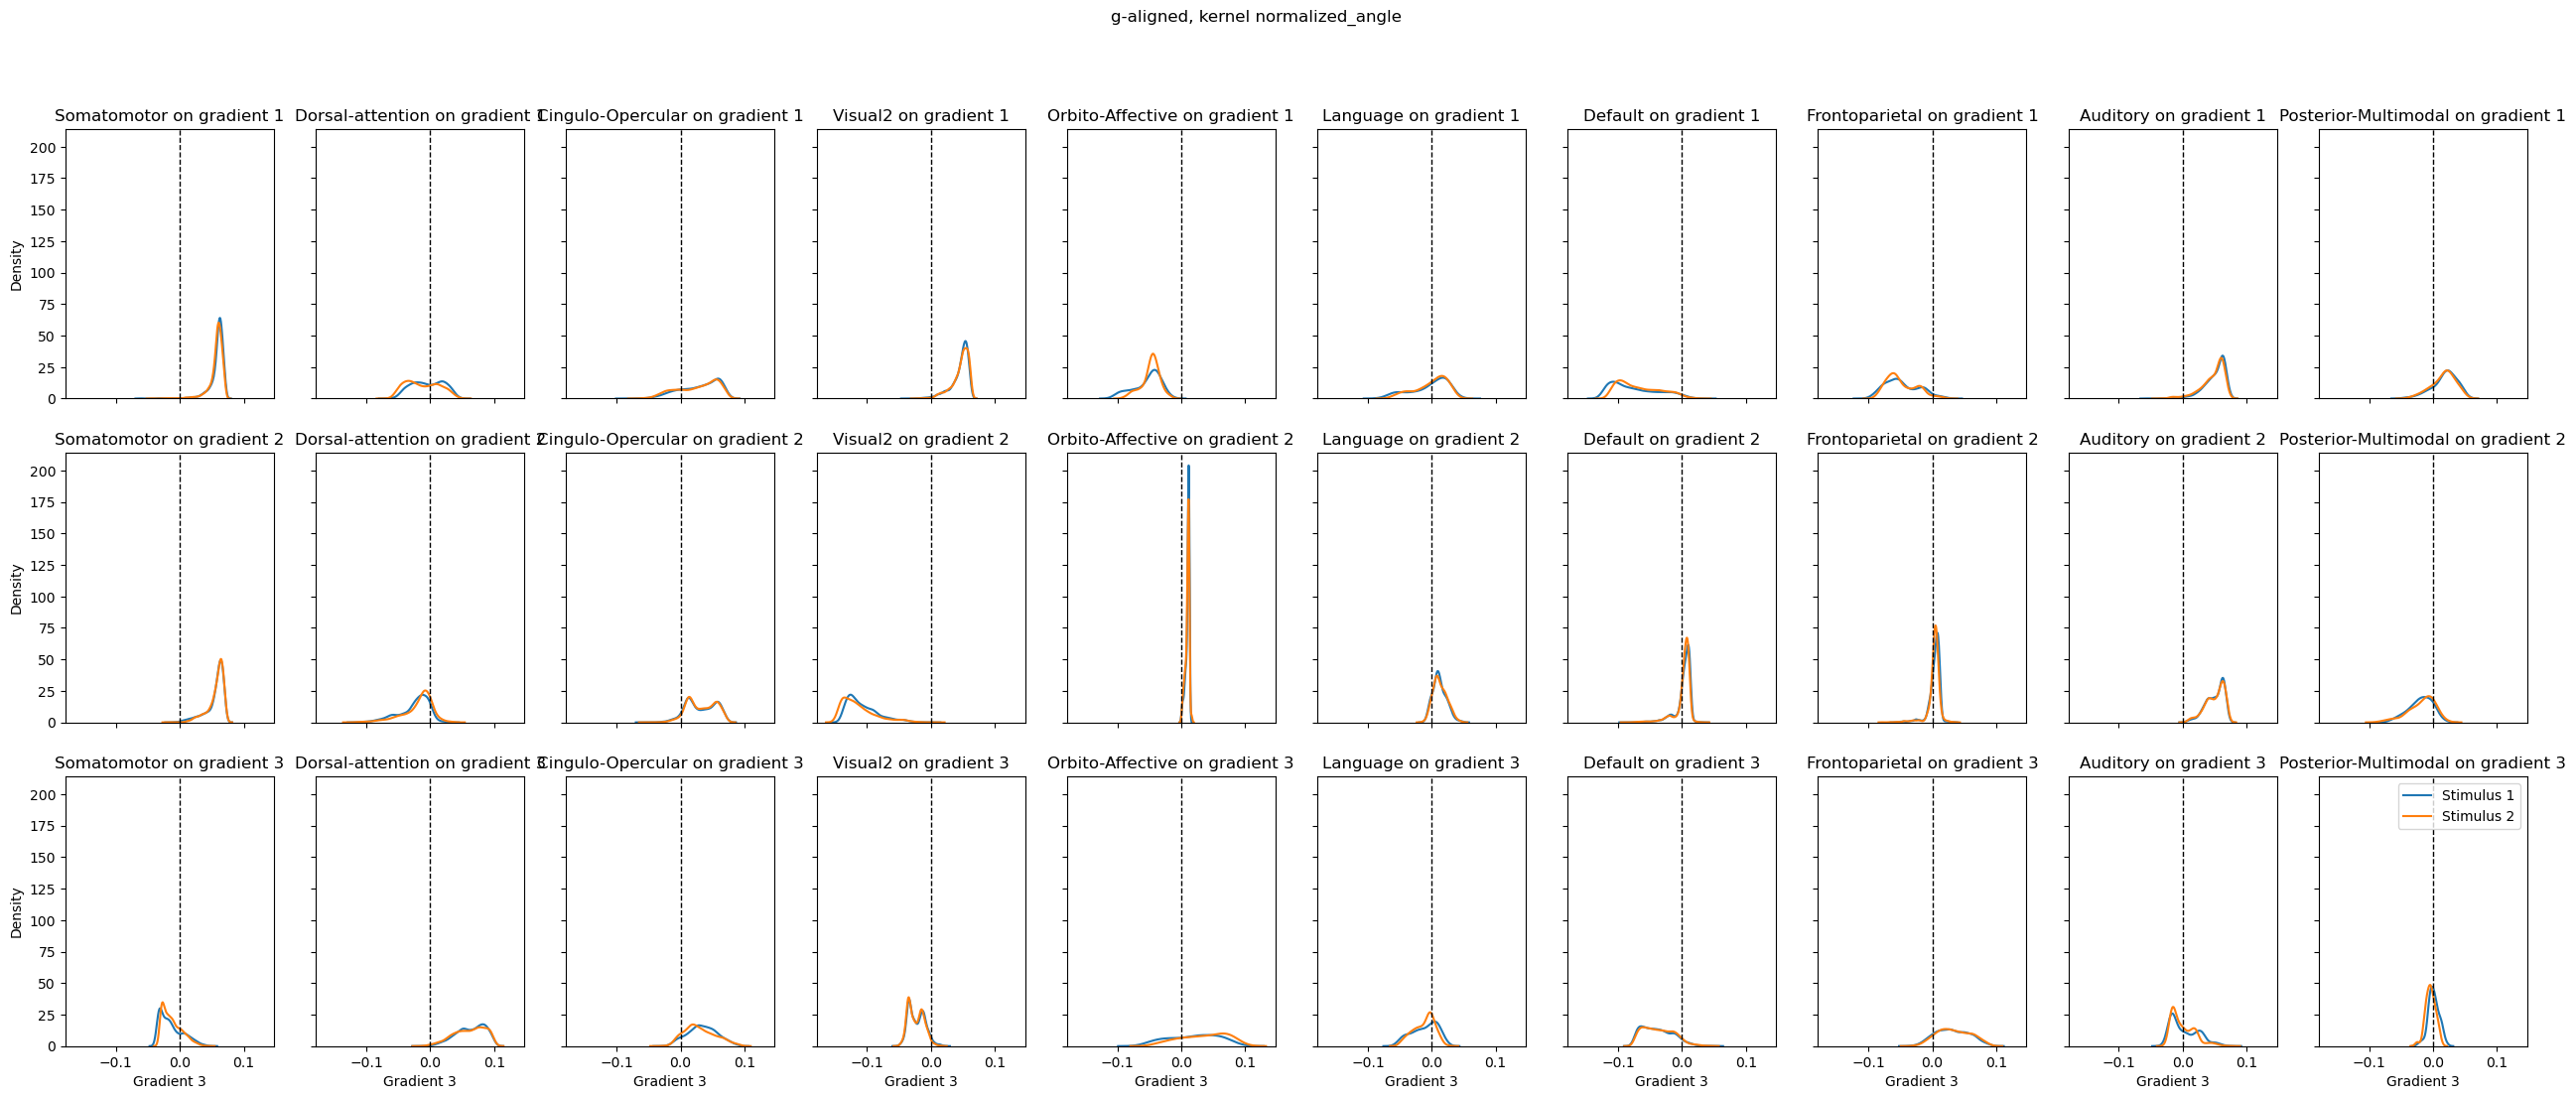

In [93]:
fig, axes = plt.subplots(3, 10, figsize=(32, 12), sharex=True, sharey=True)

gradients = ['1', '2', '3']

netwoks_valid = stim1_df['ca_network_name'].dropna().unique()

for i, grad in enumerate(gradients):

    for j, net in enumerate(netwoks_valid):
        if pd.isna(net):
            continue
        ax = axes[i, j]

        sns.kdeplot(stim1_df[stim1_df['ca_network_name'] == net][f'Gradient {grad}'], label='Stimulus 1', ax=axes[i,j])
        sns.kdeplot(stim2_df[stim2_df['ca_network_name'] == net][f'Gradient {grad}'], label='Stimulus 2', ax=axes[i,j])
        ax.axvline(0, color='black', linestyle='--', linewidth=1)
        axes[i,j].set(title=f'{net} on gradient {grad}')
        
plt.legend()
fig.suptitle(f'{spec}, kernel {kernel}')        
plt.show()